<a href="https://colab.research.google.com/github/contreraswz/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [11]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# cargar archivos
plans = pd.read_csv('/content/drive/MyDrive/TripleTen_Projects/Sprint7/plans.csv')
users = pd.read_csv('/content/drive/MyDrive/TripleTen_Projects/Sprint7/users_latam.csv')
usage = pd.read_csv('/content/drive/MyDrive/TripleTen_Projects/Sprint7/usage.csv')

In [13]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [14]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [15]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [16]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [17]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [18]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [19]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [20]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [21]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


In [22]:
# conteo de nulos en type[duration]

conteo_nulos_duration = usage[usage['duration'].isna()]['type'].value_counts()
print(conteo_nulos_duration)


type
text    22076
Name: count, dtype: int64


In [23]:
conteo_nulos_length = usage[usage['length'].isna()]['type'].value_counts()
print(conteo_nulos_length)

type
call    17896
Name: count, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  

Tabla USERS
Se tienen dos columnas con valores nulos:
city-469 nulos = 11.725%; en este caso se lo recomentable es tratar los nulos como una categoría independiente "Unknow", ya que son demasiados para borrar y perder información valiosa, pero no tenemos la certeza para información.
churn_date-3534 nulos = 88.350%; esta columna es muy especial y se debe manejar de una forma particular ya que los nulos aportan información sumamente importante, cada nulo significa el cliente esta activo. Lo recomendable es dejar la columna con sus valores intactos, y con base en ella crear una nueva columna booleana "is_churned", para facilitar la segmentación y análisis

Tabla USAGE
Tras hacer un analisis de los valores faltantes y entendiendo la tabla y sus campos se determina lo siguiente:
date- 50 nulos= 0.12%; al ser un porcentaje muy pequeño de nulos lo mas recomendable es eliminar para no introducir ruido al análisis
duration- 22076 = 55.19%; Se determinó que estos valores faltantes no responden a deficiencias en la captura de información, sino a una característica estructural del dataset: los registros correspondientes al servicio de tipo 'text' no generan una métrica de "duation". Por tanto, se recomienda mantener estos valores como nulos (NaN),o bien, aplicar una imputación con valor 0 exclusivamente en los escenarios donde sea necesario para realizar cálculos agregados.
length- 17896 = 44.74%; Se determinó que estos valores faltantes no constituyen una anomalía operativa, sino una característica estructural del dataset: el registro de "length" no aplica para el servicio de tipo 'call'. Por tanto, Se recomienda mantenerlos como valores nulos (NaN), o bien, aplicar una imputación con valor 0 exclusivamente en los escenarios donde sea necesario para realizar cálculos agregados.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [24]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [25]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`; id: Actúa como llave primaria (PK), garantizando la unicidad de los 40,000 registros transaccionales. user_id: Funciona como llave foránea (FK), con una cardinalidad de 4,000 usuarios únicos. Esto establece una relación uno a muchos (1:N), donde cada usuario genera, en promedio, 10 registros de actividad."
- Las columnas "duration" y "length": son columnas del comportamiento del uso "llamada/mensaje"...
  La columna "duration" se puede observar una discrepancia entre el promedio() y la mediana(), lo que indica un sesgo a la derecha (skewness=.74630047), esto significa que la mayoría son llamadas cortas de 3.5 min aproximadamente y llamadas muy largas de 120 min que alteran el promedio; la presencia de "0" representa servicio no concretado.
  En la columna "length", se observa una distribución simétrica y estable (skewness=.11273734), respaldada por una alta convergencia entre la media (52.12) y la mediana (50.00). La presencia de valores '0'  indica eventos con contenido nulo o servicios fallidos.

In [26]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Análisis de {col} ---")
    # Frecuencia absoluta
    print(f"Distribución:\n{users[col].value_counts()}\n")
    # Frecuencia relativa (porcentaje)
    print(f"Porcentaje:\n{users[col].value_counts(normalize=True).mul(100).round(2)}\n")
    # Cardinalidad
    print(f"Valores únicos: {users[col].nunique()}\n")
    # Nulos
    print(f"Valores nulos: {users[col].isna().sum()}\n")
    print("-" * 30)

--- Análisis de city ---
Distribución:
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Porcentaje:
city
Bogotá      22.88
CDMX        20.67
Medellín    17.45
GDL         12.74
Cali        12.01
MTY         11.53
?            2.72
Name: proportion, dtype: float64

Valores únicos: 7

Valores nulos: 469

------------------------------
--- Análisis de plan ---
Distribución:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64

Porcentaje:
plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64

Valores únicos: 2

Valores nulos: 0

------------------------------


- La columna `city`; Se identificaron valores nulos, con 565 registros (aproximadamente el 1.4% de la base total) que carecen de una categoría definida. Esta ausencia de información se presenta mediante dos variantes: valores nulos (NaN) y caracteres atípicos (?). Aunque la muestra permite observar una distribución clara en mercados estratégicos de México y Colombia
- La columna `plan`; Muestra que la base de clientes mantiene una estructura centrada en la adopción masiva del nivel de entrada. El 64.88% de los usuarios se encuentra suscrito al plan 'Basico', mientras que el 35.12% son  plan 'Premium'. Esta distribución, que presenta una relación de aproximadamente 2:1, indica que el plan 'Basico' funciona como el pilar fundamental de captación de usuarios. La integridad de esta columna es total, no hay valores nulos.

In [27]:

# explorar columna categórica de usage
usage['type'] # completa el código
# Análisis completo de la columna 'type'
print("--- Análisis de type ---")
# Distribución absoluta
print(f"Distribución:\n{usage['type'].value_counts()}\n")
# Distribución relativa (porcentaje)
print(f"Porcentaje:\n{usage['type'].value_counts(normalize=True).mul(100).round(2)}\n")
# Cardinalidad
print(f"Valores únicos: {usage['type'].nunique()}\n")
# Nulos
print(f"Valores nulos: {usage['type'].isna().sum()}")

--- Análisis de type ---
Distribución:
type
text    22092
call    17908
Name: count, dtype: int64

Porcentaje:
type
text    55.23
call    44.77
Name: proportion, dtype: float64

Valores únicos: 2

Valores nulos: 0


- La columna `type`; se observa una distribución equilibrada, con una ligera predominancia "text", el cual representa el 55.23% del volumen total, frente al 44.77% correspondiente "call". La integridad de esta columna es total, no hay valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- Tras la revisión  realizada a las columnas críticas "users (city, plan), usage(type)", se concluye que el dataset mantiene un alto nivel de integridad, a excepción de la columna city.
- "city" Es la única variable que presenta problemas de calidad. Tienes dos "valores" distintos indicando la falta de información: los nulos (NaN) y los caracteres especiales (?). Esto complica cualquier análisis de agrupación, se recomiendaConvierte todos los valores "?" en "NaN" primero. Luego, imputar todos los NaN resultantes con "unknown". Esto asegura que el total de registros coincida siempre con el total de usuarios.
- mientras que las columnas "plan" y "type" se encuentran aptas para su manipulación sin necesidad de tratamiento de valores atípicos o faltantes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [28]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce")

In [29]:
# Convertir a fecha la columna `date` de usage
usage['date']  = pd.to_datetime(usage["date"],errors="coerce")

In [30]:
# Revisar los años presentes en `reg_date` de users
years_users = users['reg_date'].dt.year
# Valores de users-reg_date
print(f"valores en users-reg_date:\n{sorted(years_users.unique())}")
# Distribución absoluta
print(f"Distribución:\n{years_users.value_counts()}\n")
# Distribución relativa (porcentaje)
print(f"Porcentaje:\n{years_users.value_counts(normalize=True).mul(100).round(2)}\n")
# Cardinalidad
print(f"Valores únicos: {years_users.nunique()}\n")
# Nulos
print(f"Valores nulos: {years_users.isna().sum()}")

valores en users-reg_date:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2026)]
Distribución:
reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64

Porcentaje:
reg_date
2024    33.25
2023    32.90
2022    32.85
2026     1.00
Name: proportion, dtype: float64

Valores únicos: 4

Valores nulos: 0


En `reg_date`, se observan valores lógicos y consistentes, sin embargo, la premisa que se otorga "Toma en cuenta que tenemos datos registrados hasta el año 2024." indica que hay valores que estan fuera de rango "2026-40 valores".

In [31]:
# Revisar los años presentes en `date` de usage
years_usage = usage['date'].dt.year
# Valores de users-reg_date
print(f"valores en users-date:\n{sorted(years_usage.unique())}")
# Distribución absoluta
print(f"Distribución:\n{years_usage.value_counts()}\n")
# Distribución relativa (porcentaje)
print(f"Porcentaje:\n{years_usage.value_counts(normalize=True).mul(100).round(2)}\n")
# Cardinalidad
print(f"Valores únicos: {years_usage.nunique()}\n")
# Nulos
print(f"Valores nulos: {years_usage.isna().sum()}")

valores en users-date:
[np.float64(2024.0), np.float64(nan)]
Distribución:
date
2024.0    39950
Name: count, dtype: int64

Porcentaje:
date
2024.0    100.0
Name: proportion, dtype: float64

Valores únicos: 1

Valores nulos: 50


En `date`, se observan 1 valor "2024" con 39950 registros y 50 valores "NaN"

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- Con respecto a la columna "user-reg_date"; No se encontraron datos nulos, sin embargo, se han identificado 40 valores fuera de rango "2026". Se recomienda nulificar esos valores para conservar el resto de la información para analisis estadisticos, pero omitir el valor "reg_date" para que el sistema lo ignore.
- Con respecto a la columna "usage-date"; Se encontraron 50 casos con valores nulos de 40,000, se recomienda excluir estos registros, su eliminación no compromete la significancia estadística del conjunto de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [32]:

# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users["age"] = users["age"].replace(-999, pd.NA)
users['age'] = users["age"].fillna(age_mediana)
# Verificar cambios
print("Edades estandarizadas")
users['age'].describe()



Edades estandarizadas


/tmp/ipykernel_7076/2759478790.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users['age'] = users["age"].fillna(age_mediana)


,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [33]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", "NA")
# Verificar cambios
print("Ciudades estandarizadas")
users["city"].value_counts()

Ciudades estandarizadas


,count
city,
Bogotá,808
CDMX,730
Medellín,616
GDL,450
Cali,424
MTY,407
NA,96


In [34]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# 3. Valiación de fechas futuras
print("Fechas en users-reg_date validadas:")
print(users['reg_date'].value_counts(dropna=False).sort_index())

Fechas en users-reg_date validadas:
reg_date
2022-01-01 00:00:00.000000000     1
2022-01-01 06:34:17.914478619     1
2022-01-01 13:08:35.828957239     1
2022-01-01 19:42:53.743435858     1
2022-01-02 02:17:11.657914478     1
                                 ..
2024-12-30 04:17:06.256564144     1
2024-12-30 10:51:24.171042768     1
2024-12-30 17:25:42.085521392     1
2024-12-31 00:00:00.000000000     1
NaT                              40
Name: count, Length: 3961, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [35]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación MAR en usage (Missing At Random) para length
# Verificación: Contar valores nulos agrupados por tipo
missing_check = usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isnull().sum())
print("Conteo de nulos por tipo:")
print(missing_check)

Conteo de nulos por tipo:
      duration  length
type                  
call         0   17896
text     22076       0


El análisis realizado marca una dependencia de las variables "duration" y "length" respecto a la variable "type", se confirma que la ausencia de datos en estas columnas es condicional (MAR): los valores nulos en "duration" ocurren exclusivamente cuando type es 'text', y los valores nulos en "length" ocurren exclusivamente cuando type es 'call'. se determina que los valores nulos no representan un error de captura ni una pérdida de información, por ello se deja el dato original.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:
# Resumen estadístico de las columnas numéricas
print("Resumen estadistico columna users-age")
users["age"].describe()

Resumen estadistico columna users-age


,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [40]:
# Distribución porcentual del tipo de plan
print("Distribución columna users-plan")
print(f"Distribución:\n{users['plan'].value_counts()}\n")
# Distribución relativa (porcentaje)
print(f"Porcentaje:\n{users['plan'].value_counts(normalize=True).mul(100).round(2)}\n")

Distribución columna users-plan
Distribución:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64

Porcentaje:
plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64



---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

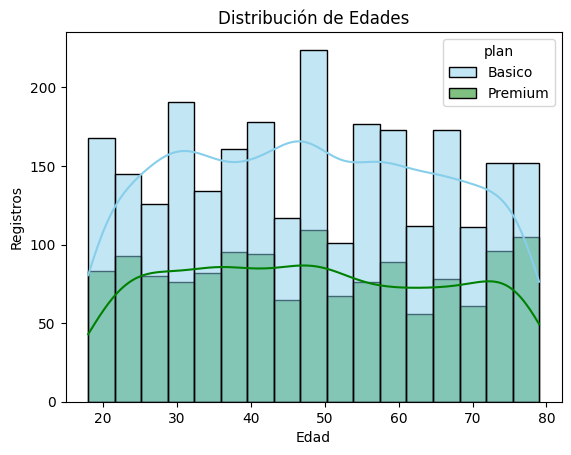

In [41]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue","green"],
    kde=True)

# Títulos y etiquetas
plt.title(f'Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Registros')
plt.show()

💡Insights:

-Distribución: La variable "age" presenta un comportamiento distinto según el plan contratado. Para los usuarios Premium, la distribución es uniforme (plana), lo que indica que no existe una concentración significativa en ningún rango de edad específico. Por el contrario, para el plan Básico, se observa una distribución bimodal, con dos picos de concentración marcados alrededor de los [30 y 50] años.

-Insight: La edad actúa como un factor diferenciador clave para el plan Básico. La existencia de dos grupos definidos sugiere que el plan Básico no es homogéneo; por lo tanto, las estrategias de marketing y retención para este segmento podrían ser más efectivas si se focalizan.

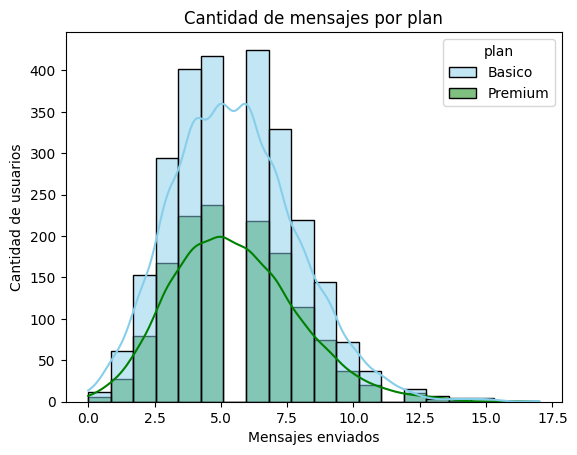

In [42]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue","green"],
    kde=True,
    bins=20)

# Títulos y etiquetas
plt.title(f'Cantidad de mensajes por plan')
plt.xlabel('Mensajes enviados')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
-Distribución:La variable de estudio "cant_mensajes" presenta un comportamiento similar en ambos planes con sesgo hacia la derecha. Esto indica que, independientemente del plan, la mayoría de los usuarios registran un volumen bajo de mensajes, con una minoría de usuarios con alto volumen de envió de mensajes que desplazan la media hacia la derecha. Si bien la forma de la distribución es consistente entre ambos grupos, se identifica una disparidad en la intensidad de uso: los usuarios del plan "Básico" presentan una mayor frecuencia, en comparación con los del plan Premium.

-Insight: La mayor intensidad de uso en el plan "Básico" sugiere que este segmento prioriza la comunicación vía mensajería como su canal principal. Estos usuarios demuestran un alto nivel de engagement con el servicio, lo cual los posiciona como el segmento objetivo ideal para estrategias de fidelización y lealtad.


Text(0, 0.5, 'Cantidad de usuarios')

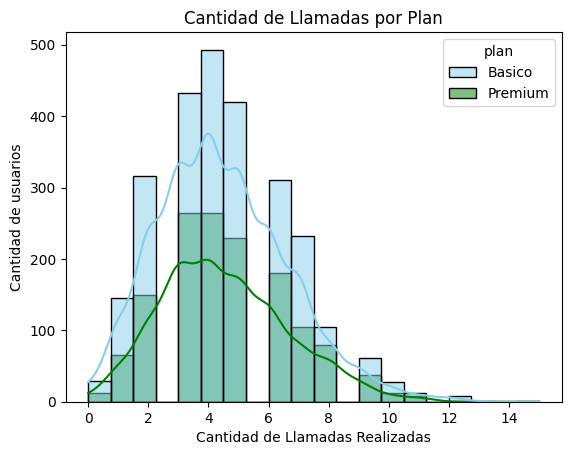

In [43]:

# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue","green"],
    kde=True,
    bins=20)

# Títulos y etiquetas

plt.title("Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de Llamadas Realizadas")
plt.ylabel("Cantidad de usuarios")


💡Insights:

-Distribución: La variable de estudio "cant_llamadas" exhibe un comportamiento análogo al observado en cant_mensajes: una distribución asimétrica con sesgo hacia la derecha. Esto confirma una tendencia consistente donde la mayoría de los usuarios realizan un número bajo de llamadas, mientras que una minoría de usuarios intensivos concentra los valores más altos. Al comparar ambos grupos, se observa que el plan "Básico" mantiene una frecuencia de uso superior en comparación con el plan "Premium".

-Insight: La consistencia del comportamiento "espejo" entre mensajería y llamadas sugiere que el plan "Básico" debería ser el foco de programas de fidelización.

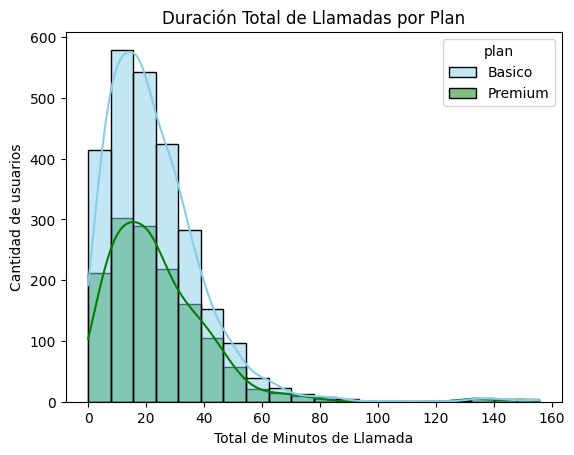

In [44]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue","green"],
    kde=True,
    bins=20)
# Títulos y etiquetas
plt.title('Duración Total de Llamadas por Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:

-Distribución: La variable "cant_minutos_llamada" muestra una distribución asimétrica con sesgo  hacia la derecha, iniciando en 0 y extendiéndose hasta un máximo de consumo cercano a los 150 minutos. Esta forma es consistente con las variables de "cant_mensajes" y "cant_llamadas", confirmando una tendencia donde la gran mayoría de la base de usuarios presenta un consumo moderado, mientras que un grupo selecto de usuarios intensivos mueve el promedio hacia la derecha.El plan "Básico" mantiene una clara superioridad frente al plan Premium.

-Insight: La convergencia de estos tres indicadores (mensajes, llamadas y minutos) refuerza la hipótesis de que el plan "Básico" es el segmento con mayor potencial para campañas de lealtad y prevención de churn.

### 5.2 Identificación de Outliers


🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


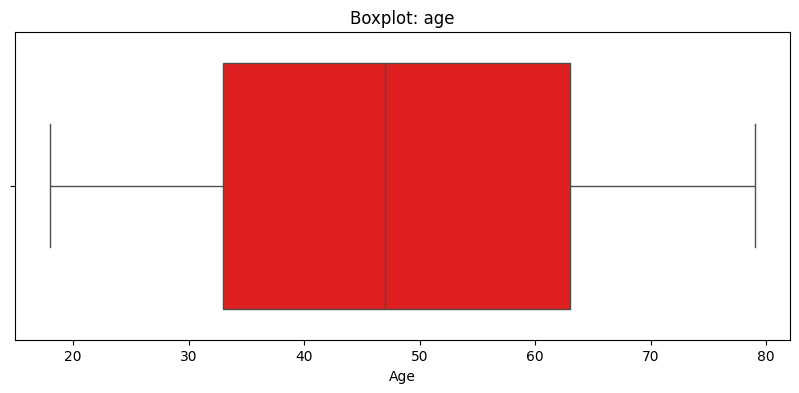

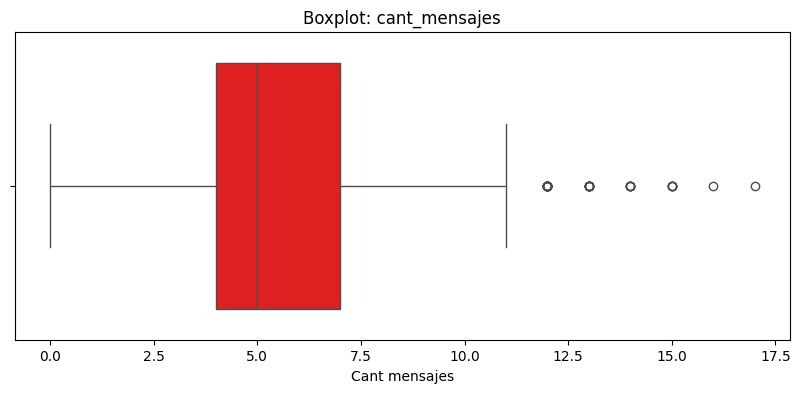

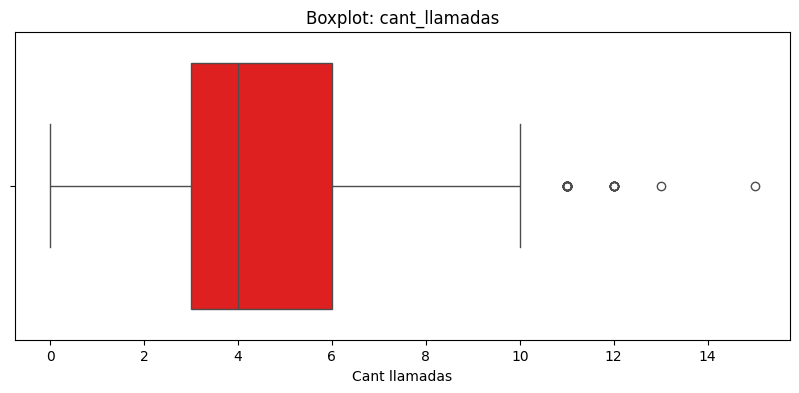

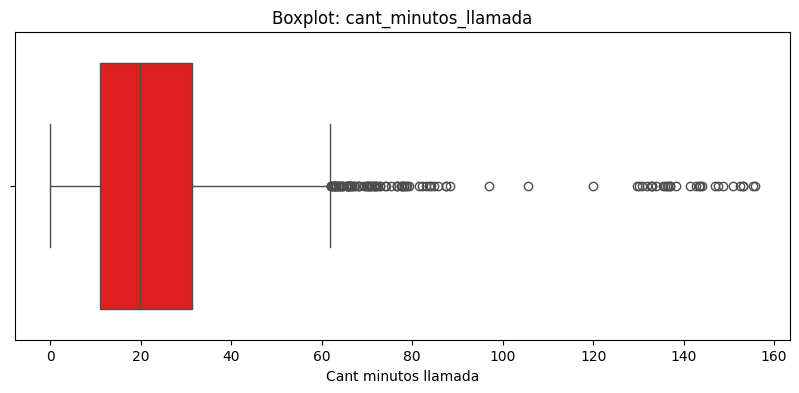

In [45]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Generar los boxplots
for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=user_profile, x=col, color='red')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col.replace('_', ' ').capitalize())
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [46]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"Columna: {col}")
    print(f"  Límite Superior: {limite_superior:.2f}")


Columna: cant_mensajes
  Límite Superior: 11.50
Columna: cant_llamadas
  Límite Superior: 10.50
Columna: cant_minutos_llamada
  Límite Superior: 61.86


In [47]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
Se observan valores por encima del límite superior en las variables de uso, los cuales se recomienda mantener al tratarse de patrones de consumo válidos de usuarios de alta actividad, y no de errores. Eliminarlos sesgaría la realidad de negocio ya que son comportamientos extremos pero posibles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso
def clasificar_uso(row):
    # Condición para Bajo uso
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    # Condición para Uso medio
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    # Todo lo demás es Alto uso
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)
user_profile['grupo_uso'].value_counts()

,count
grupo_uso,
Uso medio,2943
Bajo uso,778
Alto uso,279


In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad
def clasificar_edad(row):
    # Condición para Joven
    if row['age'] < 30:
        return 'Joven'
    # Condición para Adulto
    elif row['age'] < 60:
        return 'Adulto'
    # Todo lo demás es Adulto mAYOR
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)
user_profile['grupo_edad'].value_counts()

,count
grupo_edad,
Adulto,2018
Adulto Mayor,1222
Joven,760


In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipykernel_7076/2348919765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])


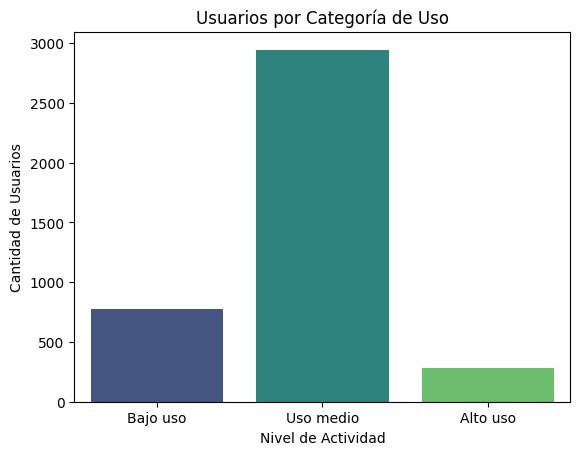

In [52]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])

# Títulos y etiquetas
plt.title('Usuarios por Categoría de Uso')
plt.xlabel('Nivel de Actividad')
plt.ylabel('Cantidad de Usuarios')

plt.show()

/tmp/ipykernel_7076/849993952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', palette='viridis', order=['Joven', 'Adulto', 'Adulto Mayor'])


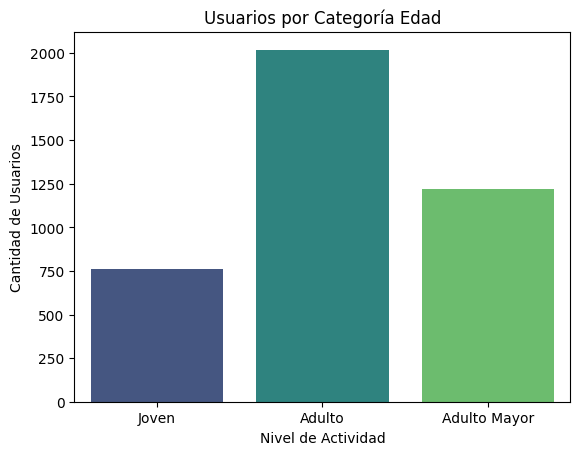

In [53]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='viridis', order=['Joven', 'Adulto', 'Adulto Mayor'])

# Títulos y etiquetas
plt.title('Usuarios por Categoría Edad')
plt.xlabel('Nivel de Actividad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Tabla Users: Inconsistencia Geográfica: Se identificó una incidencia del 11.76% de datos faltantes o mal formados en la columna city (valores nulos y caracteres "?"). Estos se reclasificaron como "unknown" para preservar la integridad de los registros sin sesgar los resultados.
Integridad Temporal: En la columna reg_date, se detectaron 40 registros con el valor "2026", identificados como valores fuera de rango respecto a la ventana temporal del análisis. Estos registros fueron excluidos/ajustados.
Identificación de Sesgo (Distribución de Uso): Las variables de uso (cant_mensajes, cant_llamadas, total_minutos_llamada) presentaban una distribución asimétrica con sesgo positivo, outliers que se decidió conservar, ya que representan a los clientes más activos, cuya eliminación habría falseado la realidad del negocio.
🔍 **Segmentos por Edad**

La estructura demográfica muestrala siguiente clasificación:

Adultos: Segmento con mayor frecuencia.

Adultos Mayores: Segundo grupo en volumen.

Jóvenes: Menor representación.

📊 **Segmentos por Nivel de Uso**
El comportamiento de uso sigue la siguiente distribución:

Uso Medio: Mayor frecuencia, representando el núcleo operativo de la base.

Bajo Uso: Segundo grupo más grande; son usuarios con actividad esporádica.

Alto Uso: Grupo minoritario, pero vital por su alta intensidad y compromiso.

La mayoría de los usuarios se encuentran en un punto de equilibrio ("Uso Medio"), lo que indica una base saludable. Sin embargo, el segmento de "Bajo Uso" debe ser monitoreado de cerca, ya que son los candidatos principales para el abandono.

💡 **Recomendaciones**
- Estrategia de Fidelización para "Alto Uso":
Dado que este grupo representa el compromiso máximo, implementar un programa de lealtad (beneficios por antigüedad, prioridad en soporte técnico) para asegurar su retención.

- Optimización y Reactivación para "Bajo Uso":
Diseñar campañas específicas o promociones temporales para incentivar a estos usuarios a aumentar su frecuencia de uso,  ofrecerles planes mas enfocados a su necesidad.

- Enfoque:
Considerando que los "Adultos" son el segmento mayoritario, la publicidad y las nuevas funcionalidades deben priorizar herramientas para este segmento. Por otro lado, para atraer al segmento "Joven", se sugiere ofertar paquetes centrados en datos y redes sociales, áreas donde este grupo suele ser más activo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`